In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_pickle('../data/processed/emails_with_anomalies.pkl')
print(f"Loaded {len(df):,} emails")

Loaded 458,386 emails


In [2]:
# Parse sender-receiver pairs
edges = []
for _, row in df.iterrows():
    sender = row['from']
    if pd.isna(row['to']):
        continue
    for recipient in str(row['to']).split(','):
        recipient = recipient.strip()
        if recipient and '@' in recipient:
            edges.append((sender, recipient))

print(f"Total email connections: {len(edges):,}")

# Build graph
G = nx.DiGraph()
edge_counts = {}
for s, r in edges:
    key = (s, r)
    edge_counts[key] = edge_counts.get(key, 0) + 1

for (s, r), weight in edge_counts.items():
    G.add_edge(s, r, weight=weight)

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

Total email connections: 2,894,630
Nodes: 76,755
Edges: 300,071


In [3]:
# Key metrics for forensic analysis
degree_centrality = nx.degree_centrality(G)
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)

# Top 20 most central nodes
top_central = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:20]
print("Most central communicators:")
for node, score in top_central:
    print(f"  {node}: {score:.4f}")

Most central communicators:
  sally.beck@enron.com: 0.0237
  kenneth.lay@enron.com: 0.0234
  jeff.dasovich@enron.com: 0.0212
  outlook.team@enron.com: 0.0209
  david.forster@enron.com: 0.0205
  jeff.skilling@enron.com: 0.0197
  tana.jones@enron.com: 0.0188
  sara.shackleton@enron.com: 0.0181
  klay@enron.com: 0.0174
  technology.enron@enron.com: 0.0163
  vince.kaminski@enron.com: 0.0152
  louise.kitchen@enron.com: 0.0150
  gerald.nemec@enron.com: 0.0137
  mark.taylor@enron.com: 0.0133
  john.lavorato@enron.com: 0.0123
  tracey.kozadinos@enron.com: 0.0120
  kay.mann@enron.com: 0.0119
  julie.clyatt@enron.com: 0.0118
  bodyshop@enron.com: 0.0114
  david.oxley@enron.com: 0.0114


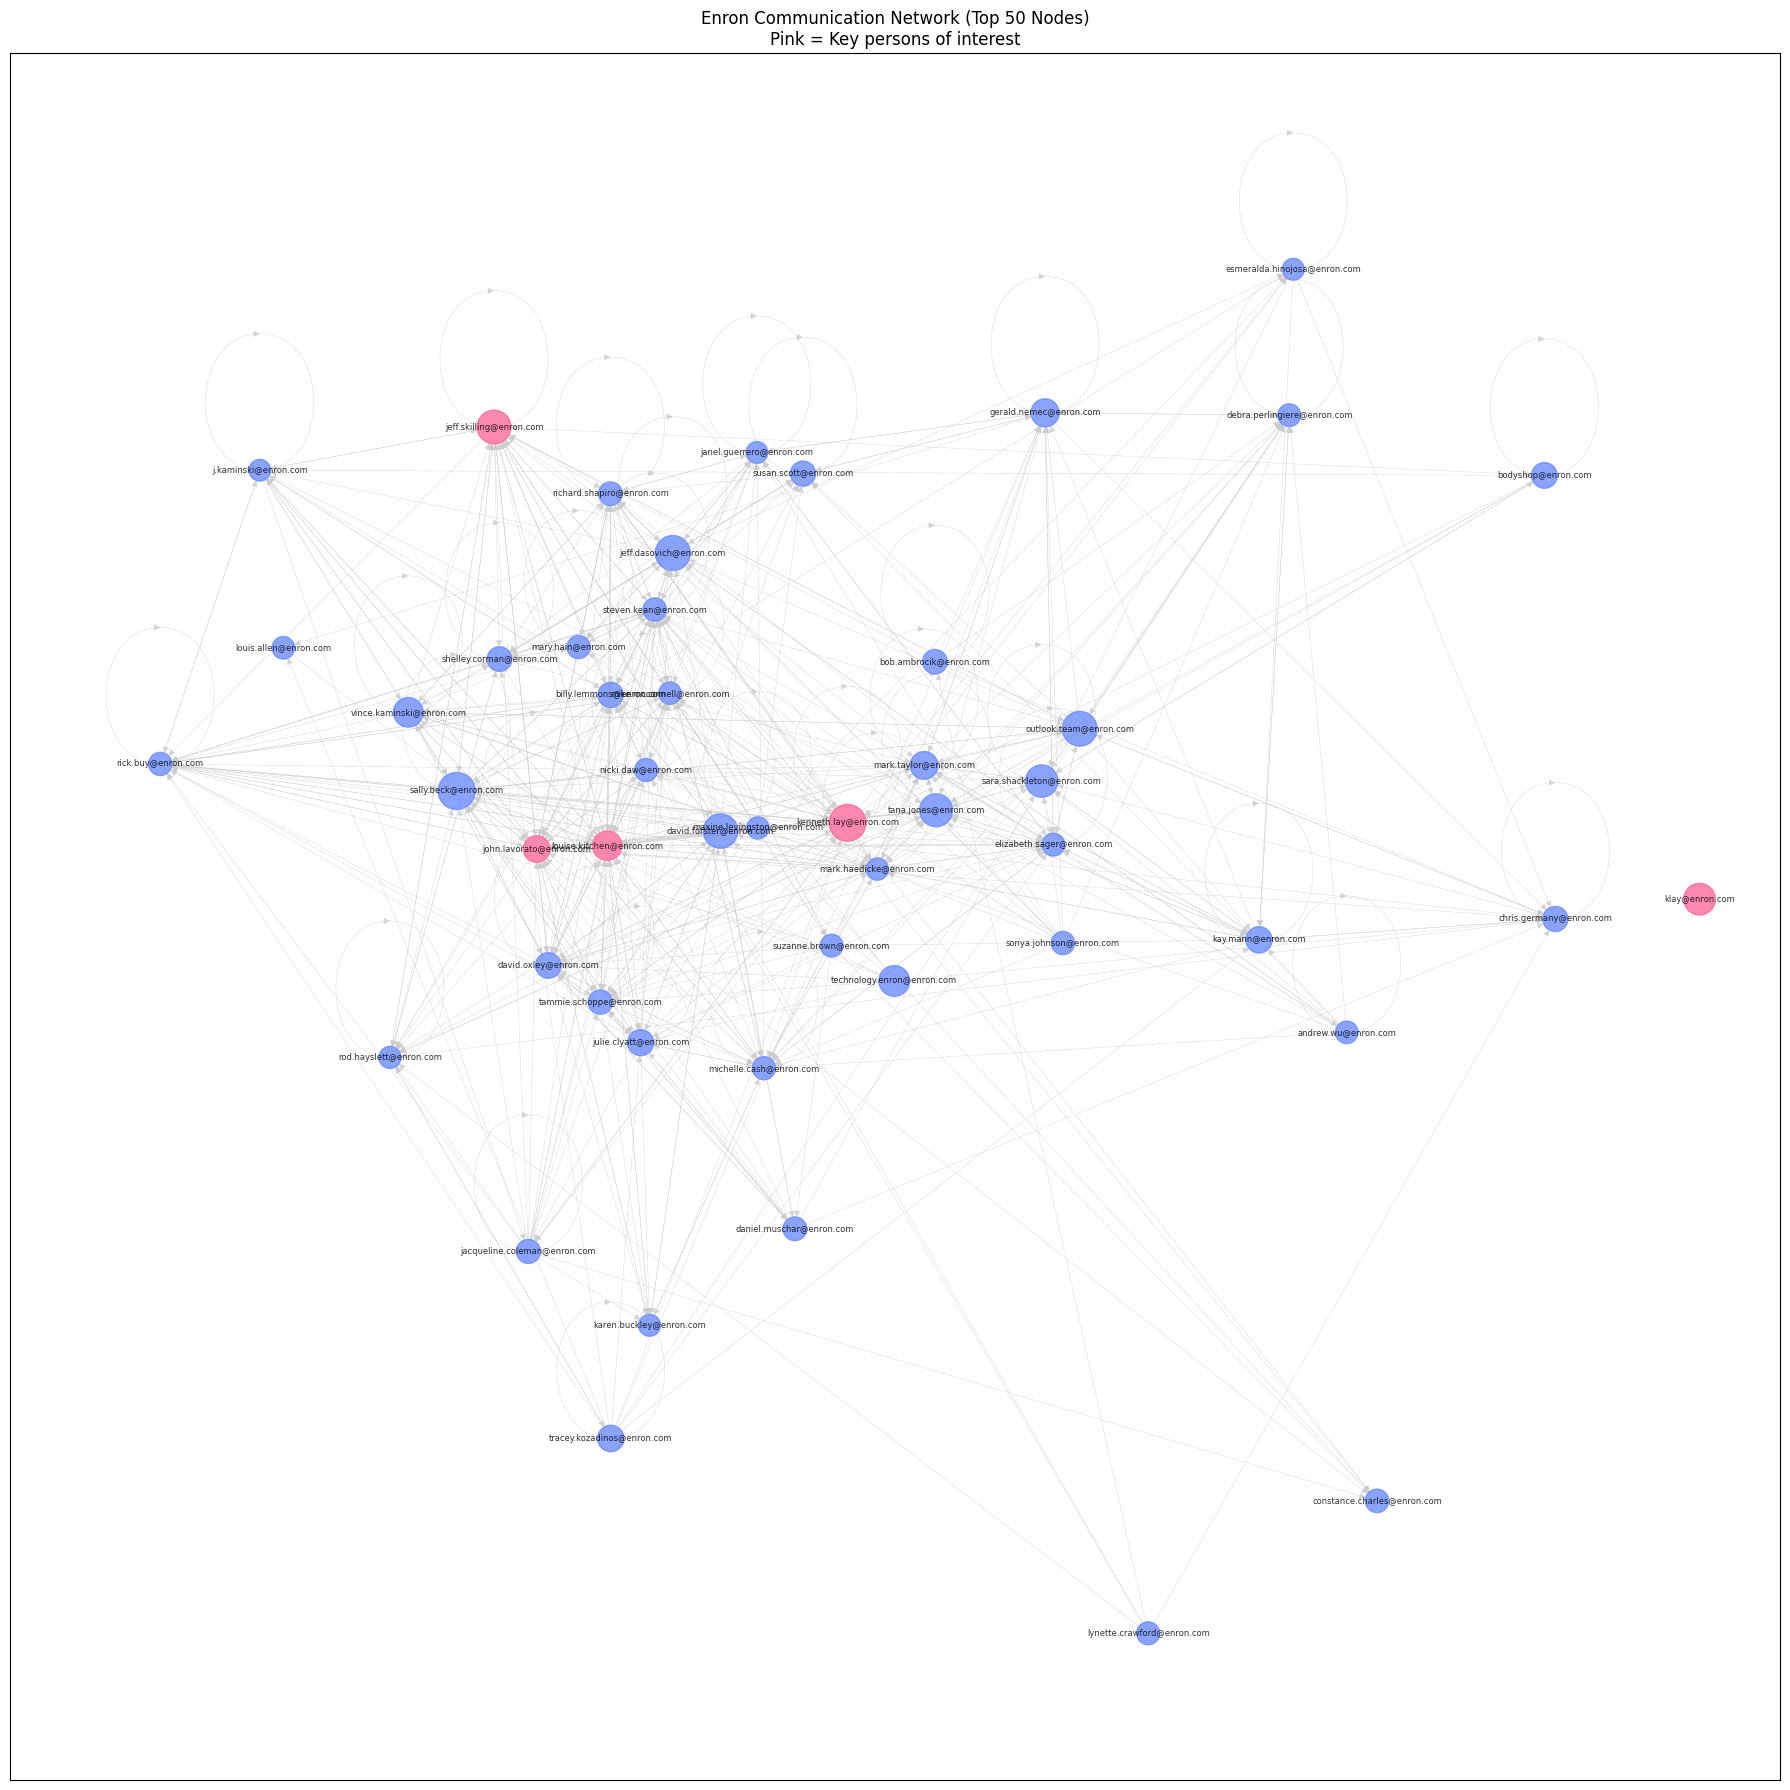

In [4]:
# Subgraph of top 50 most active communicators
top_nodes = [n for n, _ in sorted(degree_centrality.items(),
             key=lambda x: x[1], reverse=True)[:50]]
subG = G.subgraph(top_nodes)

fig, ax = plt.subplots(figsize=(18, 18))
pos = nx.spring_layout(subG, k=2, seed=42)

# Node sizes by centrality
node_sizes = [degree_centrality.get(n, 0) * 30000 for n in subG.nodes()]

# Highlight key fraud people
node_colors = []
fraud_emails = ['kenneth.lay@enron.com', 'jeff.skilling@enron.com', 
                'klay@enron.com', 'louise.kitchen@enron.com',
                'john.lavorato@enron.com']
for n in subG.nodes():
    if n in fraud_emails:
        node_colors.append('#ff6b9d')
    else:
        node_colors.append('#6c8cff')

nx.draw_networkx(
    subG, pos, ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color='#cccccc',
    alpha=0.8,
    font_size=6,
    arrows=True,
    width=0.3
)
ax.set_title('Enron Communication Network (Top 50 Nodes)\nPink = Key persons of interest')
plt.tight_layout()
plt.savefig('../results/figures/communication_network.png', dpi=150)
plt.show()

In [5]:
# Community detection
from networkx.algorithms.community import greedy_modularity_communities

# Use undirected version for community detection
G_undirected = G.to_undirected()

# Get top 1000 nodes to make community detection feasible
top_1000 = [n for n, _ in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:1000]]
subG_community = G_undirected.subgraph(top_1000)

communities = list(greedy_modularity_communities(subG_community))
print(f"Detected {len(communities)} communities")

# Check which community fraud people are in
fraud_emails = ['kenneth.lay@enron.com', 'jeff.skilling@enron.com', 
                'klay@enron.com', 'louise.kitchen@enron.com',
                'john.lavorato@enron.com', 'andrew.fastow@enron.com']

for i, community in enumerate(communities):
    fraud_in_community = [p for p in fraud_emails if p in community]
    if fraud_in_community:
        print(f"\nCommunity {i} ({len(community)} members):")
        print(f"  Fraud-involved: {fraud_in_community}")
        # Show some other members of same community
        others = [p for p in list(community)[:10] if p not in fraud_emails]
        print(f"  Other members: {others[:5]}")

Detected 20 communities

Community 0 (412 members):
  Fraud-involved: ['louise.kitchen@enron.com']
  Other members: ['robin.jordan@enron.com', 'julissa.marron@enron.com', 'rob.walls@enron.com', 'scott.palmer@enron.com', 'scott.neal@enron.com']

Community 2 (232 members):
  Fraud-involved: ['kenneth.lay@enron.com', 'jeff.skilling@enron.com', 'john.lavorato@enron.com', 'andrew.fastow@enron.com']
  Other members: ['ava.garcia@enron.com', 'rebecca.torres@enron.com', 'vince.kaminski@enron.com', 'cynthia.morrow@enron.com', 'henry.emery@painewebber.com']

Community 4 (12 members):
  Fraud-involved: ['klay@enron.com']
  Other members: ['officename1234@aol.com', 'lharpold@lrmlaw.com', 'blauderback@soes.com', 'dberg13046@aol.com', 'jane.burnap@intermat.com']


/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78018/3192414180.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_emails.groupby(user_emails['datetime'].dt.to_period('M')).size()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78018/3192414180.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_emails.groupby(user_emails['datetime'].dt.to_period('M')).size()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78018/3192414180.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_emails.groupby(user_emails['datetime'].dt.to_period('M')).size()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78018/3192414180.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_emails.groupby(user_emails['datetime'

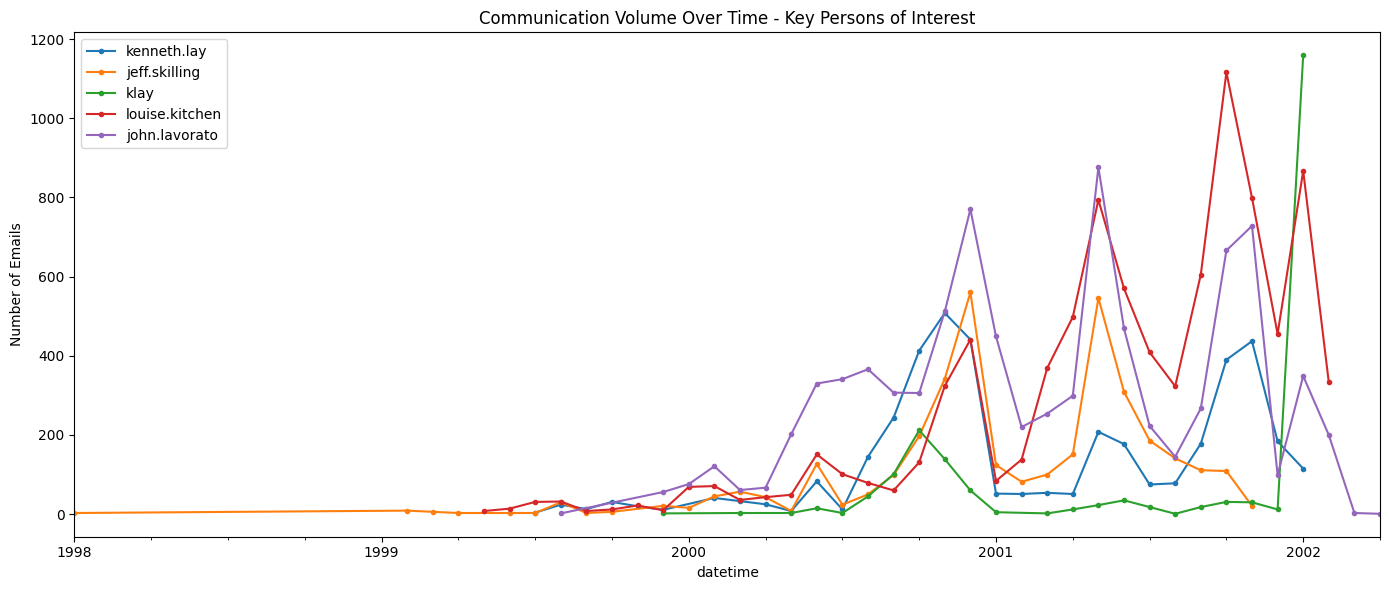

In [6]:
# Network changes over time - monthly edge counts for key fraud users
fraud_emails_all = ['kenneth.lay@enron.com', 'jeff.skilling@enron.com', 
                    'klay@enron.com', 'louise.kitchen@enron.com',
                    'john.lavorato@enron.com']

fig, ax = plt.subplots(figsize=(14, 6))

for fraud_email in fraud_emails_all:
    user_emails = df[(df['from'] == fraud_email) | (df['to'].str.contains(fraud_email, na=False))]
    monthly = user_emails.groupby(user_emails['datetime'].dt.to_period('M')).size()
    if len(monthly) > 3:
        monthly.plot(ax=ax, marker='o', markersize=3, label=fraud_email.split('@')[0])

ax.set_title('Communication Volume Over Time - Key Persons of Interest')
ax.set_ylabel('Number of Emails')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/fraud_users_communication_timeline.png', dpi=150)
plt.show()

In [7]:
# Export network data for MATLAB
edge_df = pd.DataFrame([(s, t, d['weight']) for s, t, d in G.edges(data=True)],
                        columns=['source', 'target', 'weight'])
edge_df.to_csv('../results/network_edges.csv', index=False)

metrics_df = pd.DataFrame({
    'node': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'in_degree': [in_degree.get(n, 0) for n in degree_centrality.keys()],
    'out_degree': [out_degree.get(n, 0) for n in degree_centrality.keys()]
})
metrics_df.to_csv('../results/network_metrics.csv', index=False)

df.to_pickle('../data/processed/emails_with_anomalies.pkl')
print("Exported network data and saved results")

Exported network data and saved results
